# 1 Décomposition QR par la méthode de Householder

### 1.1 Montrer que les matrices de réflexion $Q_i$ sont orthogonales

#### a) Orthogonalité d’une matrice de Householder

Une matrice de Householder est définie par :

$$
H = I - 2\frac{v v^T}{v^T v},
$$

où $v \neq 0$.  
On veut démontrer que :

$$
H^T H = I.
$$

Comme $v v^T$ est symétrique :

$$
(v v^T)^T = v v^T,
$$
Deux matrices, une colonne et l'autre ligne de même longueure et identique, donnera le même résultats malgré la transposée.

Donc :

$$
H^T = H.
$$

Ainsi :

$$
H^T H = H^2.
$$

Calculons $H^2$ :

$$
H^2
= \left(I - 2\frac{v v^T}{v^T v}\right)^2
= I - 4\frac{v v^T}{v^T v}
  + 4\frac{v v^T v v^T}{(v^T v)^2}.
$$

Nous savons que :

$$
v v^T v = (v^T v) v,
$$

donc :

$$
v v^T v v^T = (v^T v) v v^T.
$$

Ainsi :

$$
4\frac{v v^T v v^T}{(v^T v)^2}
= 4\frac{(v^T v) v v^T}{(v^T v)^2}
= 4\frac{v v^T}{v^T v}.
$$

En substituant :

$$
H^2
= I - 4\frac{v v^T}{v^T v}
  + 4\frac{v v^T}{v^T v}
= I.
$$

Donc :

$$
H^T H = I,
$$

ce qui montre que toute matrice de Householder est orthogonale.

---

#### b) Orthogonalité des matrices $Q_i$ ####

Les matrices $Q_i$ sont définies par blocs :

$$
Q_i =
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}
\end{pmatrix}.
$$

La transposée est :

$$
Q_i^T =
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}^T
\end{pmatrix}
=
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}
\end{pmatrix},
$$

puisque $I_i$  et  $H_{m,i}$ sont symétriques.

Alors :

$$
Q_i^T Q_i =
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}
\end{pmatrix}
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}
\end{pmatrix}
=
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}H_{m,i}
\end{pmatrix}.
$$

Comme $H_{m,i}$ est orthogonale :

$$
H_{m,i}H_{m,i} = I_{m-i}.
$$

Donc :

$$
Q_i^T Q_i = I_m.
$$

Ainsi, chaque matrice $Q_i$ est orthogonale.

### 1.2 Démontrer l’équation (3.5) et que la matrice $Q$ est orthogonale

On applique successivement les matrices $Q_i$ à la matrice $A$ :

$$
Q_{n-1} Q_{n-2} \cdots Q_1 Q_0 A = R,
$$

où $R$ est triangulaire supérieure.

On multiplie à gauche par la transposée du produit :

$$
(Q_{n-1} Q_{n-2} \cdots Q_0)^T.
$$

Comme chaque $Q_i$ est orthogonale :

$$
Q_i^T = Q_i^{-1}.
$$

On obtient :

$$
A = Q_0^T Q_1^T \cdots Q_{n-2}^T Q_{n-1}^T R.
$$

On définit alors :

$$
Q = Q_0^T Q_1^T \cdots Q_{n-1}^T.
$$

Ce qui donne :

$$
A = QR.
$$

C’est exactement l’équation (3.5) de l’énoncé.

---

### Orthogonalité de $Q$
Comme chaque $Q_i$ est orthogonale, chaque $Q_i^T$ l’est aussi.

Le produit de matrices orthogonales est orthogonale.

Ainsi :

$$
Q^T Q = 
(Q_{n-1} \cdots Q_1 Q_0)
(Q_0^T Q_1^T \cdots Q_{n-1}^T)
= I.
$$

Donc, la matrice $Q$ de la décomposition QR est orthogonale.

### 1.3 Impémentation de la fonction householder_qr

In [8]:
import numpy as np

def householder_qr(A, step=False):
    """Calcule la décomposition QR d’une matrice A en utilisant les réflexions de Householder. """
    
    m, n = A.shape  # donne les valeurs correspondantes à m et n de la matrice A
    Q = np.eye(m)   # Crée une matrice identité de taille m x m pour stocker les transformations de Householder
    R = A.copy()    # Crée une copie de la matrice A pour stocker les résultats de la décomposition

    for k in range(n):  # on passe au travers de chaque colonne de la matrice A

        # Extract the column vector to be transformed
        x = R[k:, k]  # vecteur colonne tronqué à partir de la ligne k et de la colonne k

        # Compute the Householder vector
        e = np.zeros_like(x)  # Crée un vecteur de même taille que x, rempli de zéros
        sign = 1 if x[0] >= 0 else -1  # Choisit le signe pour éviter les problèmes de cancellation numérique
        e[0] = sign * np.linalg.norm(x)  # Met la norme de x dans la première composante du vecteur e

        u = x + e  # Calcule le vecteur de Householder selon la définition du TP (x + sign*||x||*e1)
        beta = u @ u  # Calcule u^T u (un scalaire), utilisé dans la formule de Householder

        if beta == 0:  # Cas dégénéré : aucune transformation nécessaire
            continue

        # Create the Householder matrix
        H_k = np.eye(m)  # Matrice identité m x m
        H_k[k:, k:] -= 2 * np.outer(u, u) / beta  # Applique la formule H = I - 2 uu^T / (u^T u)

        # Apply the transformation to R and accumulate Q
        R = H_k @ R  # Applique la réflexion à R pour annuler les éléments sous la diagonale
        Q = Q @ H_k  # Accumule les transformations pour construire la matrice Q finale

    
        if step:
            print("Q:\n", Q)
            print("R:\n", R)
    return Q, R

# Example usage

A = np.array([[4, 1], [2, 3], [1, 2]], dtype=float)
Q, R = householder_qr(A)    
print("Q:\n", Q)    
print("R:\n", R)
# Verify that A = Q @ R
print("Q @ R:\n", Q @ R)
print("A:\n", A)
print("Verification (Q @ R == A):", np.allclose(Q @ R, A))

Q:
 [[-0.87287156  0.48107024  0.08164966]
 [-0.43643578 -0.69487923 -0.57154761]
 [-0.21821789 -0.53452248  0.81649658]]
R:
 [[-4.58257569e+00 -2.61861468e+00]
 [ 4.39110249e-16 -2.67261242e+00]
 [ 4.62000826e-17 -1.30304986e-16]]
Q @ R:
 [[4. 1.]
 [2. 3.]
 [1. 2.]]
A:
 [[4. 1.]
 [2. 3.]
 [1. 2.]]
Verification (Q @ R == A): True


#### 1.4 teste de la fonction householder_qr ####

Nous allons utiliser la matrice $A$ 4x3:
$$
A = \begin{pmatrix}
1 & 2 & 1 \\
2 & 4 & 5 \\
0 & 3 & 0 \\
0 & 2 & -5
\end{pmatrix}
$$


In [9]:
A = np.array([
    [1, 2, 1],
    [2, 4, 5],
    [0, 3, 0],
    [0, 2, -5]
])

print("Matrice A (4x3) :\n", A)

Q, R = householder_qr(A)
print("Matrice Q (4x4) :\n", Q)
print("Matrice R (4x3) :\n", R)
R_numpy = np.linalg.qr(A, mode='reduced')[1]
print("Matrice R de NumPy (4x3) :\n", R_numpy)

Matrice A (4x3) :
 [[ 1  2  1]
 [ 2  4  5]
 [ 0  3  0]
 [ 0  2 -5]]
Matrice Q (4x4) :
 [[-0.38461538  0.07848871  0.16539843 -0.90473968]
 [-0.92307692 -0.03270363 -0.06891601  0.37697487]
 [ 0.          0.82903697 -0.55837997 -0.03015799]
 [ 0.          0.55269132  0.81000355  0.19602693]]
Matrice R (4x3) :
 [[-2.23076923e+00 -4.46153846e+00 -5.00000000e+00]
 [ 1.30814513e-02  3.61865646e+00 -2.84848601e+00]
 [ 2.75664050e-02  0.00000000e+00 -4.22919938e+00]
 [-1.50789947e-01  0.00000000e+00 -1.78044623e-16]]
Matrice R de NumPy (4x3) :
 [[-2.23606798 -4.47213595 -4.91934955]
 [ 0.         -3.60555128  2.77350098]
 [ 0.          0.         -4.37123464]]


### 1.5 Vérification des matrices Q et R

In [10]:
Q, R = householder_qr(A, step=True)
print("Matrice Q (4x4) :\n", Q)
print("Matrice R (4x3) :\n", R)
print("Matrice Q^T @ Q possède-t-elle les propriétés d'une matrice orthogonale ?\n", Q.T @ Q)

Q:
 [[-0.38461538 -0.92307692  0.          0.        ]
 [-0.92307692  0.38461538  0.          0.        ]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]
R:
 [[-2.23076923 -4.46153846 -5.        ]
 [-0.15384615 -0.30769231  1.        ]
 [ 0.          3.          0.        ]
 [ 0.          2.         -5.        ]]
Q:
 [[-0.38461538  0.07848871 -0.7652649  -0.5101766 ]
 [-0.92307692 -0.03270363  0.31886037  0.21257358]
 [ 0.          0.82903697  0.36655884 -0.42229411]
 [ 0.          0.55269132 -0.42229411  0.71847059]]
R:
 [[-2.23076923 -4.46153846 -5.        ]
 [ 0.01308145  3.61865646 -2.84848601]
 [-0.12754415  0.          2.94050751]
 [-0.08502943  0.         -3.03966166]]
Q:
 [[-0.38461538  0.07848871  0.16539843 -0.90473968]
 [-0.92307692 -0.03270363 -0.06891601  0.37697487]
 [ 0.          0.82903697 -0.55837997 -0.03015799]
 [ 0.          0.55269132  0.81000355  0.19602693]]
R:
 [[-2.23076923e+00 -4.46153846e+00 -5.00000000e+

# 2 Mesures imprécises dans un jeu de bataille navale

#### 2.1 Modification du code de décomposition de QR

In [11]:
import numpy as np
import xlwings as xw
import matplotlib.pyplot as plt

# ouvrir le fichier Excel
wb = xw.Book('bataille_navale_equipe050.csv')

# sélectionner une feuille
sheet = wb.sheets['bataille_navale_equipe050']

# lire une cellule
Coordonne_x = sheet.range('A2:A9').value
Coordonne_y = sheet.range('B2:B9').value
print(Coordonne_x)
print(Coordonne_y)

A = np.zeros((len(Coordonne_x),4))


for i in range(len(Coordonne_x)):
    A[i,0] = 1
    A[i,1] = Coordonne_x[i]
    A[i,2] = Coordonne_x[i]**2
    A[i,3] = Coordonne_y[i]

print(A)
def householder_qr(A):
    """Calcule la décomposition QR d’une matrice A en utilisant les réflexions de Householder. """
    
    m, n = A.shape  # donne les valeurs correspondantes à m et n de la matrice A
    Q = np.eye(m)   # Crée une matrice identité de taille m x m pour stocker les transformations de Householder
    R = A.copy()    # Crée une copie de la matrice A pour stocker les résultats de la décomposition

    for k in range(n):  # on passe au travers de chaque colonne de la matrice A

        # Extract the column vector to be transformed
        x = R[k:, k]  # vecteur colonne tronqué à partir de la ligne k et de la colonne k

        # Compute the Householder vector
        e = np.zeros_like(x)  # Crée un vecteur de même taille que x, rempli de zéros
        sign = 1 if x[0] >= 0 else -1  # Choisit le signe pour éviter les problèmes de cancellation numérique
        e[0] = sign * np.linalg.norm(x)  # Met la norme de x dans la première composante du vecteur e

        u = x + e  # Calcule le vecteur de Householder selon la définition du TP (x + sign*||x||*e1)
        beta = u @ u  # Calcule u^T u (un scalaire), utilisé dans la formule de Householder

        if beta == 0:  # Cas dégénéré : aucune transformation nécessaire
            continue

        # Create the Householder matrix
        H_k = np.eye(m)  # Matrice identité m x m
        H_k[k:, k:] -= 2 * np.outer(u, u) / beta  # Applique la formule H = I - 2 uu^T / (u^T u)

        # Apply the transformation to R and accumulate Q
        R = H_k @ R  # Applique la réflexion à R pour annuler les éléments sous la diagonale
        Q = Q @ H_k  # Accumule les transformations pour construire la matrice Q finale


    return Q, R

 

Q, R = householder_qr(A)       
print("R:\n", R)
print("Verification (Q @ R == A):", np.allclose(Q @ R, A))

[2635.01796295324, 2564.31109162505, 2493.55845637202, 2422.8958772041, 2352.12613749554, 2281.42637488933, 2210.70350039799, 2139.98934105288]
[10.5950280022769, 160.220694291491, 304.4563807953, 438.606686747962, 567.445625512324, 681.158037160169, 793.070284088819, 891.761432720425]
[[1.00000000e+00 2.63501796e+03 6.94331967e+06 1.05950280e+01]
 [1.00000000e+00 2.56431109e+03 6.57569137e+06 1.60220694e+02]
 [1.00000000e+00 2.49355846e+03 6.21783378e+06 3.04456381e+02]
 [1.00000000e+00 2.42289588e+03 5.87042443e+06 4.38606687e+02]
 [1.00000000e+00 2.35212614e+03 5.53249737e+06 5.67445626e+02]
 [1.00000000e+00 2.28142637e+03 5.20490630e+06 6.81158037e+02]
 [1.00000000e+00 2.21070350e+03 4.88720997e+06 7.93070284e+02]
 [1.00000000e+00 2.13998934e+03 4.57955438e+06 8.91761433e+02]]
R:
 [[-2.82842712e+00 -6.75287992e+03 -1.61967890e+07 -1.36023097e+03]
 [ 1.69587671e-16 -4.58312144e+02 -2.18844382e+06  8.17141081e+02]
 [-1.69586388e-16  1.68649309e-15  6.48216743e+04 -5.53421834e+01]
 [-

### 2.2 Résolution approximative de l'équation

In [12]:
a_2 = R[2,3]/R[2,2]
a_1 = (R[1,3]-R[1,2]*a_2)/R[1,1]
a_0 = (R[0,3]-R[0,2]*a_2-R[0,1]*a_1)/R[0,0]


print(f"y(x) = {a_2}x^2+{a_1}x+{a_0}]")



y(x) = -0.0008537604741404132x^2+2.293776773615609x+-106.48671685423868]


### 2.3 Trajectoir prédite


[2635.01796295324, 2564.31109162505, 2493.55845637202, 2422.8958772041, 2352.12613749554, 2281.42637488933, 2210.70350039799, 2139.98934105288]
[10.5950280022769, 160.220694291491, 304.4563807953, 438.606686747962, 567.445625512324, 681.158037160169, 793.070284088819, 891.761432720425]


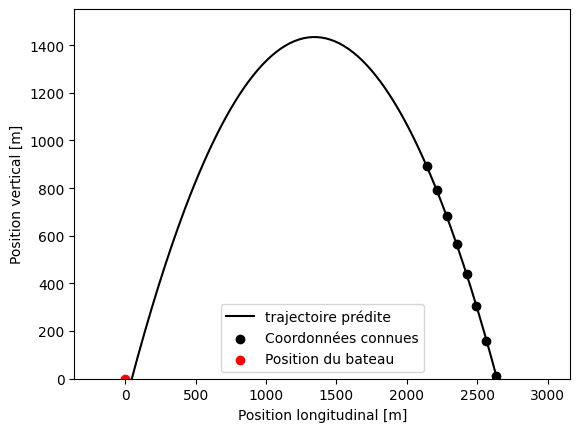

In [13]:
import xlwings as xw
import matplotlib.pyplot as plt
import numpy as np


# ouvrir le fichier Excel
wb = xw.Book('bataille_navale_equipe050.csv')

# sélectionner une feuille
sheet = wb.sheets['bataille_navale_equipe050']

# lire une cellule
Coordonne_x = sheet.range('A2:A9').value
Coordonne_y = sheet.range('B2:B9').value
print(Coordonne_x)
print(Coordonne_y)

Coordonne_x_predit = np.linspace(-200, 3000, 200)
Coordonne_y_predit = []


def trajectoire(x):
    return a_2*x**2+a_1*x+a_0   
   
for i in Coordonne_x_predit:
    Coordonne_y_predit.append(trajectoire(i))
             
plt.plot(Coordonne_x_predit, Coordonne_y_predit, color="black", label="trajectoire prédite")
plt.scatter(Coordonne_x, Coordonne_y, color="black", label="Coordonnées connues")
plt.scatter(0, 0, color="red", label="Position du bateau")
plt.ylim(bottom=0)
plt.legend()
plt.xlabel("Position longitudinal [m]")
plt.ylabel("Position vertical [m]")
plt.show()


### 2.4 Position de l'impact du projectil avec la méthode de la bissection

La résolution pour y=0 en utilisant la méthode de la bissection trouve un zéro à: 47.25534904120315
La résolution pour y=0 en utilisant la méthode de la bissection trouve un zéro à: 2639.419477320417


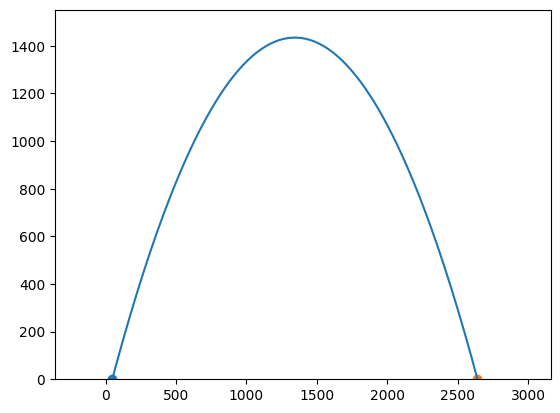

In [14]:
import numpy as np


n = 10000

Y = []

def f(x):
    return trajectoire(x)

for i in Coordonne_x_predit:
    Y.append(f(i))

def trouve_zero(a, b):
    if f(a)*f(b) > 0 :
        print("erreur, f(a) et f(b) sont de même signe. Faute initiale.")
        
    else:
        for i in range(100):
            f_a = f(a)
            f_b = f(b)
            f_m = f((a+b)/2)
            if f_a*f_m <= 0:
                b = (a+b)/2

            elif f_b*f_m <= 0:
                a = (a+b)/2

            else:
                print("erreur, f(a) et f(b) sont de même signe. Faute lors de la résolution.")
                break

        print(f"La résolution pour y=0 en utilisant la méthode de la bissection trouve un zéro à: {(a+b)/2}")
        plt.scatter((a+b)/2, f((a+b)/2))

trouve_zero(-500, 500)
trouve_zero(2500, 3000)
plt.plot(Coordonne_x_predit,Y)
plt.ylim(bottom=0)
plt.show()

Étant donné que le tir terminera sa course à 47.25 mètres de notre position, nous pouvons conclure que nous seront en sécurité si notre embarcation est de faible taille (un kayak par exemple). Cependant, si notre embarcation mesure plus de 47.25 mètres tel le USNS Apalachicola (103 mètres) ou même une frégates de classe Halifax (100 mètres), il se pourrait que le projectil nous touche dépendament de notre orientation.

# TP3.3 : Modèle épidémiologique SIR sur réseau

## Question a) Résolution analytique de l'équation (3.14)

L'équation à résoudre est la suivante :
$$u = \frac{1}{[1 + T(\kappa - 1)(1 - u)]^2} \equiv f(u)$$

Pour simplifier les calculs, on pose la constante $A = T(\kappa - 1)$. L'équation devient :
$$u = \frac{1}{[1 + A(1 - u)]^2}$$

En multipliant par le dénominateur, on obtient :
$$u [1 + A(1 - u)]^2 = 1$$

On développe ensuite l'expression:
$$u [1 + 2A(1 - u) + A^2(1 - u)^2] = 1$$
$$u [1 + 2A - 2Au + A^2(1 - 2u + u^2)] = 1$$
$$u [1 + 2A - 2Au + A^2 - 2A^2u + A^2u^2] = 1$$

En regroupant les termes selon les puissances de $u$, on obtient:
$$A^2 u^3 - 2A(A + 1) u^2 + (A + 1)^2 u - 1 = 0$$

On remarque que si $u = 1$, l'équation (3.14) donne $1 = 1 / [1 + 0]^2 = 1$. Donc, $(u - 1)$ est un facteur du polynôme.

Par division polynomiale, on obtient :
$$(u - 1) [A^2 u^2 - (A^2 + 2A) u + 1] = 0$$

On cherche les racines de la partie droite de l'équation. Les deux autres racines sont donc :
$$u = \frac{(A^2 + 2A) \pm \sqrt{A^4 + 4A^3}}{2A^2}$$

Les trois racines sont :

1.  $$u_1 = \frac{A^2 + 2A + \sqrt{A^4 + 4A^3}}{2A^2}$$
2.  $$u_2 = \frac{A^2 + 2A - \sqrt{A^4 + 4A^3}}{2A^2}$$
3.  $$u_3 = 1$$

Le résultat des racines peut être calculé manuellement, ou numériquement avec la fonction suivante:

In [15]:
import numpy as np

def get_analytical_roots(T, kappa):
    """Calcule les 3 racines analytiques pour une valeur de T donnée."""
    if T == 0:
        return [1.0] # Cas limite
    
    A = T * (kappa - 1)
    delta = A**4 + 4*A**3
    
    u1 = (A**2 + 2*A + np.sqrt(delta)) / (2 * A**2)
    u2 = (A**2 + 2*A - np.sqrt(delta)) / (2 * A**2)
    u3 = 1.0
    
    return sorted([u1, u2, u3])

print(f"Racines analytiques pour T=0.3 : {get_analytical_roots(0.3, 5)}")

Racines analytiques pour T=0.3 : [np.float64(0.29250033360026706), 1.0, np.float64(2.3741663330663996)]


## Question b) Sélection de la solution physique

La variable $u$ représente une probabilité, elle doit donc obligatoirement satisfaire la condition $0 \le u \le 1$. Parmi les solutions obtenues à la question précédente, la valeur $u \approx 2.374$ est rejetée car elle est supérieure à 1, ce qui est physiquement impossible. La solution $u = 1$ correspond au cas trivial où aucune transmission n’a lieu au sein de la population, ce qui implique une taille d'épidémie $R_\infty = 0$. Puisque l'énoncé précise que $u$ est la plus petite solution non négative de l'équation (3.14), la solution physiquement pertinente pour décrire la propagation de la maladie est la racine $u \approx 0.2925$ (pour $T=0.3$).

## Question c) Analyse de la taille finale de l'épidémie $R_\infty$

Pour obtenir les différentes valeurs de $u$, on utilise les équations analytiques développées précedement. Le script présenté ci-dessous détaille l'implémentation de cet algorithme ainsi que la boucle de calcul nécessaire pour balayer l'intervalle complet de transmissibilité et identifier le seuil épidémique.

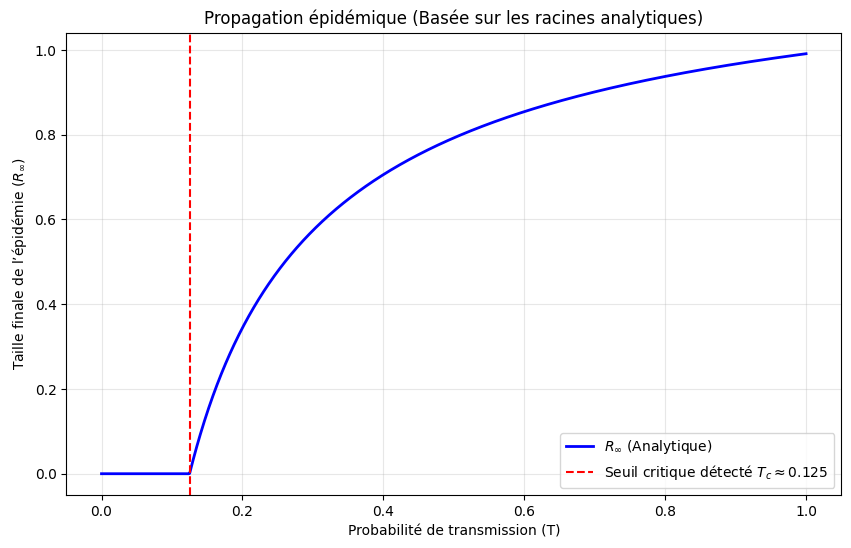

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
kappa = 5

def R_inf(u, T, kappa):
    return 1 - (1 - T*(1-u))/(1 + T*(kappa-1)*(1-u))

# Calcul de R_inf pour T de 0 à 1
T_values = np.linspace(0, 1, 1000)
R_inf_values = []

for t_val in T_values:
    roots = get_analytical_roots(t_val, kappa)
    u_physique = roots[0]
    
    res = R_inf(u_physique, t_val, kappa)
    R_inf_values.append(res)

# Seuil Tc (où R_inf décolle de zéro)
R_array = np.array(R_inf_values)
seuil_detection = 1e-4 
indices_positifs = np.where(R_array > seuil_detection)[0]

if len(indices_positifs) > 0:
    idx_seuil = indices_positifs[0]
    Tc_detecte = T_values[idx_seuil]
else:
    Tc_detecte = 0

# 3. Graphique
plt.figure(figsize=(10, 6))
plt.plot(T_values, R_inf_values, color='blue', lw=2, label='$R_{\\infty}$ (Analytique)')
plt.axvline(x=Tc_detecte, color='red', linestyle='--', 
            label=f'Seuil critique détecté $T_c \\approx {Tc_detecte:.3f}$')

plt.xlabel('Probabilité de transmission (T)')
plt.ylabel('Taille finale de l’épidémie ($R_{\\infty}$)')
plt.title('Propagation épidémique (Basée sur les racines analytiques)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

L'analyse du graphique de la taille finale de l'épidémie $R_\infty$ en fonction de la probabilité de transmission $T$ révèle un changement qualitatif majeur qui correspond à une transition de phase épidémique détectée numériquement à $T_c \approx 0.125$. Pour des valeurs de $T$ inférieures à ce seuil, la fraction de la population infectée demeure nulle car la maladie ne possède pas une transmissibilité suffisante pour se propager et finit par s'éteindre naturellement après seulement quelques contacts au sein du réseau. Dès que $T$ franchit cette valeur critique, on observe un « décollage » soudain de la courbe où $R_\infty$ croît rapidement, montrant qu'une fraction significative de la population est désormais atteinte par l'agent pathogène. Ce phénomène s'interprète physiquement comme l'atteinte d'un seuil de percolation où la condition de stabilité de la solution triviale $u=1$ est rompue lorsque $2T(\kappa-1) = 1$, ce qui donne précisément $T_c = 1 / [2(5-1)] = 0.125$. À ce point précis, le virus devient assez contagieux pour former une composante géante d'infection à travers le réseau. On peut finalement observer que $R_\infty$ croît de plus en plus lentement à mesure que $T$ augmente pour tendre vers une valeur maximale proche de 1, ce qui signifie que la quasi-totalité de la population finit par être infectée lorsque la transmission est totale. Par exemple, pour un taux de transmission maximal ($T=1$) avec une moyenne de $\kappa=5$, on calcule que $R_\infty$ atteint environ 99,1 % de la population, ce qui signifie que la quasi-totalité des individus finit par être infectée sans jamais atteindre le 100 % absolu pour des raisons statistiques.

## Question d) Résolution numérique par relaxation et Newton-Raphson

On fait maintenant la résolution numérique de l’équation (3.14) par implémentations personnelles des méthodes de relaxation et de Newton-Raphson. On applique ces algorithmes à vingt valeurs de $T$ réparties uniformément sur l’intervalle $[0, 1]$ afin de confronter les résultats numériques aux solutions analytiques développées à la première question. Le code développé pour les deux méthodes est le suivant:

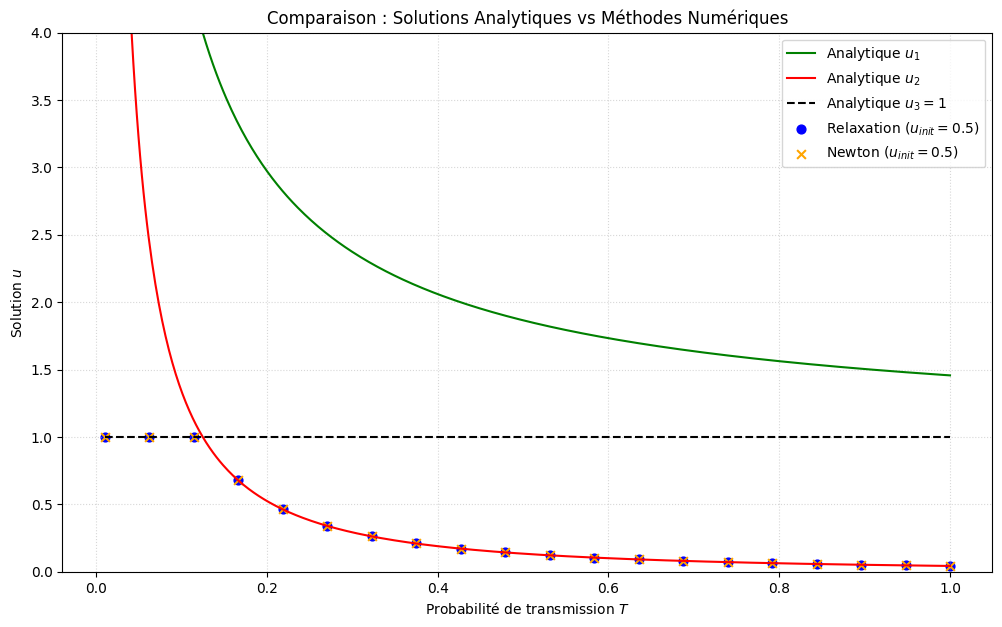

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres et solveurs ---
kappa = 5
tol = 1e-10
max_iter = 1000

def f(u, T, kappa):
    return 1 / (1 + T*(kappa-1)*(1-u))**2

def df_du(u, T, kappa):
    A = T * (kappa - 1)
    return (2 * A) / (1 + A * (1 - u))**3

def g(u, T, kappa):
    return f(u, T, kappa) - u

def g_prime(u, T, kappa):
    return df_du(u, T, kappa) - 1

def solve_relaxation(T, kappa, u_start, tol, max_iter):
    u = u_start
    for _ in range(max_iter):
        u_new = f(u, T, kappa)
        if abs(u_new - u) < tol: return u_new
        u = u_new
    return u

def solve_newton(T, kappa, u_start, tol, max_iter):
    u = u_start
    for _ in range(max_iter):
        val, der = g(u, T, kappa), g_prime(u, T, kappa)
        if der == 0: return None
        u_new = u - val / der
        if abs(u_new - u) < tol: return u_new
        u = u_new
    return u


T_20 = np.linspace(0.01, 1, 20)

u_relax_points = []
u_newton_points = []

for t in T_20:
    u_r = solve_relaxation(t, kappa, 0.5, tol, max_iter)
    u_n = solve_newton(t, kappa, 0.5, tol, max_iter)
    
    u_relax_points.append(u_r)
    u_newton_points.append(u_n)


T_cont = np.linspace(0.01, 1, 500)

u1_analytique = []
u2_analytique = []
u3_analytique = np.ones_like(T_cont)

for t in T_cont:
    A = t * (kappa - 1)
    delta = A**4 + 4*A**3
    
    # Formules dérivées à la question a)
    u1 = (A**2 + 2*A + np.sqrt(delta)) / (2 * A**2)
    u2 = (A**2 + 2*A - np.sqrt(delta)) / (2 * A**2)
    
    u1_analytique.append(u1)
    u2_analytique.append(u2)

# Graphique Final
plt.figure(figsize=(12, 7))

# Tracé des lignes analytiques
plt.plot(T_cont, u1_analytique, color='green', label='Analytique $u_1$', lw=1.5)
plt.plot(T_cont, u2_analytique, color='red', label='Analytique $u_2$', lw=1.5)
plt.plot(T_cont, u3_analytique, color='black', linestyle='--', label='Analytique $u_3 = 1$', lw=1.5)

# Tracé des points numériques
plt.scatter(T_20, u_relax_points, color='blue', marker='o', s=40, label='Relaxation ($u_{init}=0.5$)')
plt.scatter(T_20, u_newton_points, color='orange', marker='x', s=40, label='Newton ($u_{init}=0.5$)')

plt.ylim(0, 4)
plt.xlabel('Probabilité de transmission $T$')
plt.ylabel('Solution $u$')
plt.title('Comparaison : Solutions Analytiques vs Méthodes Numériques')
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.show()

L'analyse du graphique de comparaison montre une correspondance parfaite entre les points calculés numériquement et les branches analytiques obtenues à la première question. Avec un point de départ fixé à $u_{init} = 0.5$, la méthode de relaxation et celle de Newton-Raphson convergent toutes deux vers la solution physique $u_2$ ou vers la solution triviale $u_3$ selon la région de $T$ explorée. La méthode de relaxation ne permet pas d'atteindre la branche $u_1$ car elle est mathématiquement contrainte de ne converger que vers des points fixes stables satisfaisant la condition de stabilité $|f'(u)| < 1$. Puisque la dérivée $f'(u)$ est supérieure à l'unité au voisinage de la racine $u_1$, cette dernière agit comme un répulseur qui éloigne systématiquement les itérations de relaxation vers une autre solution. En revanche, la méthode de Newton-Raphson parvient à identifier cette troisième solution instable lorsqu'on utilise une valeur initiale plus élevée, par exemple $u_{init} = 3.5$, car son mécanisme de recherche de racine basé sur la pente locale ne dépend pas de la nature attractive ou répulsive du point fixe.

On peut se convaincre de cette observation en traçant la fonction f(u) et sa dérivé pour plusieurs valeurs de T.

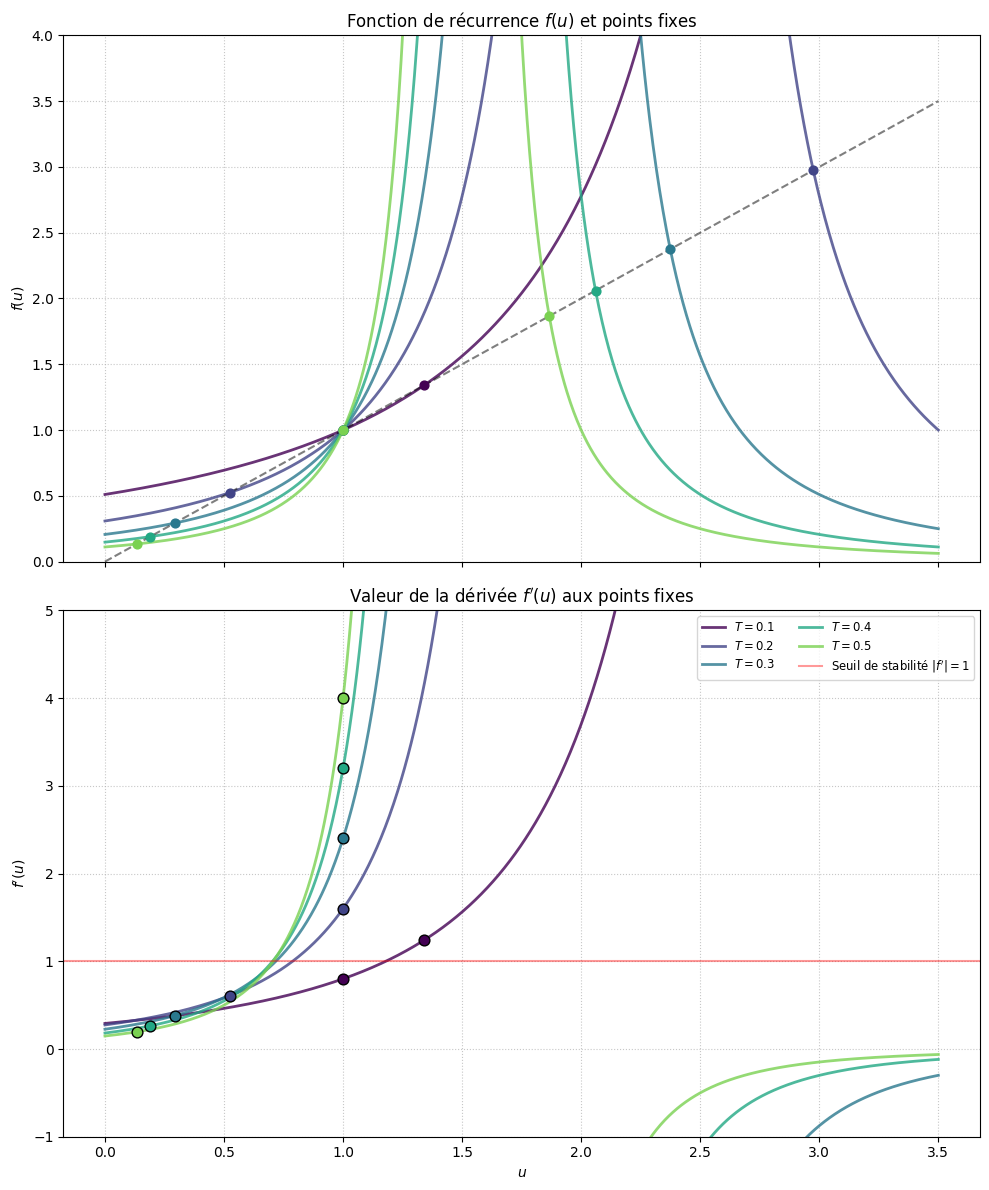

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def f(u, T, k):
    with np.errstate(divide='ignore', invalid='ignore'):
        denom = 1 + T * (k - 1) * (1 - u)
        return 1 / (denom**2)

def df(u, T, k):
    with np.errstate(divide='ignore', invalid='ignore'):
        denom = 1 + T * (k - 1) * (1 - u)
        num = 2 * T * (k - 1)
        return num / (denom**3)

def get_roots(T, k):
    """Calcul analytique des racines de f(u) = u"""
    if T == 0: return [1.0]
    A = T * (k - 1)
    delta = A**4 + 4*A**3
    u1 = (A**2 + 2*A + np.sqrt(delta)) / (2 * A**2)
    u2 = (A**2 + 2*A - np.sqrt(delta)) / (2 * A**2)
    u3 = 1.0
    return [u1, u2, u3]

k = 5
T_values = [0.1, 0.2, 0.3, 0.4, 0.5]
u_range = np.linspace(0, 3.5, 1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(T_values)))

for T, color in zip(T_values, colors):
    f_vals = f(u_range, T, k)
    df_vals = df(u_range, T, k)
    
    f_vals[f_vals > 50] = np.nan
    df_vals[np.abs(df_vals) > 50] = np.nan

    ax1.plot(u_range, f_vals, color=color, lw=2, alpha=0.8)
    ax2.plot(u_range, df_vals, color=color, lw=2, alpha=0.8, label=f'$T={T}$')

    roots = get_roots(T, k)
    for r in roots:
        if 0 <= r <= 3.5:
            val_f = f(r, T, k)
            val_df = df(r, T, k)
            ax1.scatter(r, val_f, color=color, s=40, zorder=5)
            ax2.scatter(r, val_df, color=color, s=60, edgecolors='black', zorder=5)


ax1.plot(u_range, u_range, 'k--', alpha=0.5, label='$y = u$')
ax1.set_ylabel('$f(u)$')
ax1.set_title('Fonction de récurrence $f(u)$ et points fixes')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.set_ylim(0, 4)

ax2.axhline(y=1, color='red', linestyle='-', alpha=0.4, label='Seuil de stabilité $|f\'|=1$')
ax2.set_xlabel('$u$')
ax2.set_ylabel("$f'(u)$")
ax2.set_title('Valeur de la dérivée $f\'(u)$ aux points fixes')
ax2.legend(loc='upper right', fontsize='small', ncol=2)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.set_ylim(-1, 5)

plt.tight_layout()
plt.show()

La méthode de **relaxation** s'arrêtee que sur les points "attractifs" (stables), là où la pente f'(u) est plus petite que 1 (sous la ligne rouge du graphique). Si un point est "repoussant" (instable), la relaxation s'en éloigne forcément. 



À l'inverse, **Newton** utilise la pente pour "viser" directement la cible. Cela lui permet d'atteindre n'importe quel point, même s'il est instable, à condition de partir du bon endroit. En résumé, la relaxation suit la tendance naturelle du système, tandis que Newton calcule précisément la position de chaque solution.

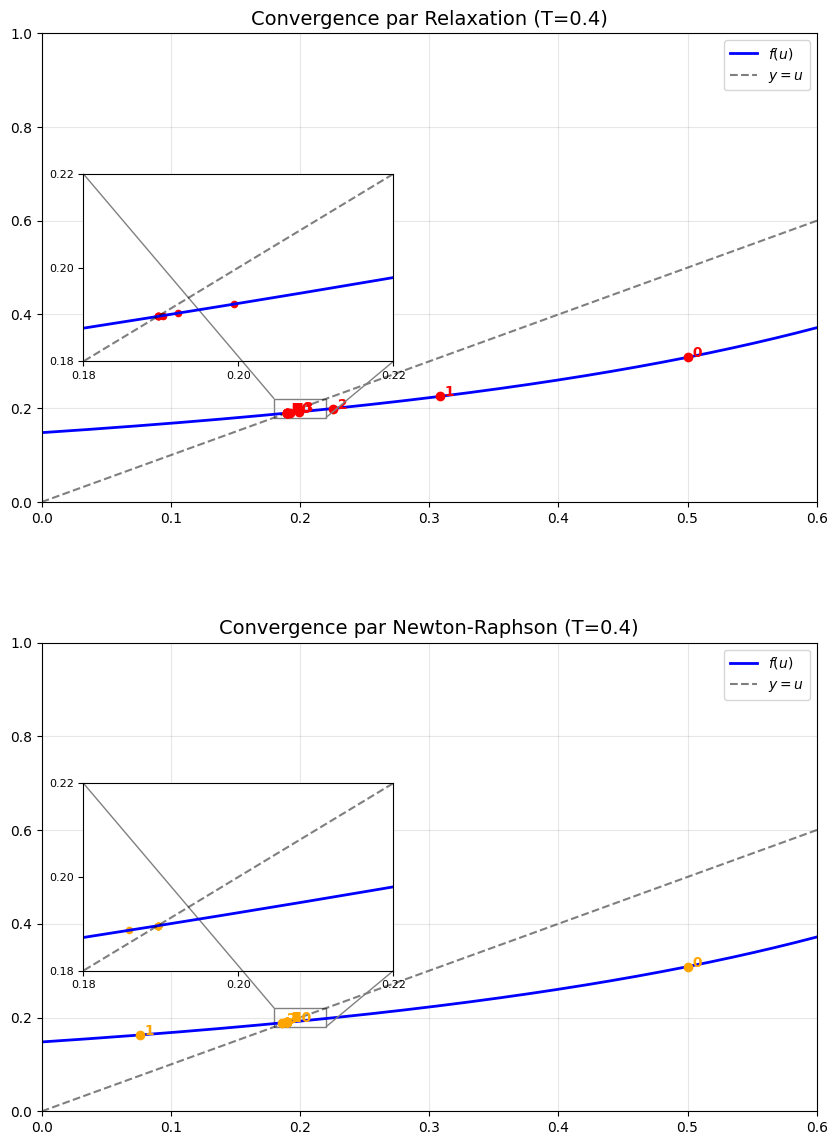

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

kappa = 5


# --- 2. TES SOLVEURS MODIFIÉS (Pour garder l'historique des points) ---
def solve_relaxation_history(T, kappa, u_start, n_iter):
    history = [u_start]
    u = u_start
    for _ in range(n_iter):
        u = f(u, T, kappa)
        history.append(u)
    return history

def solve_newton_history(T, kappa, u_start, n_iter):
    history = [u_start]
    u = u_start
    for _ in range(n_iter):
        val, der = g(u, T, kappa), g_prime(u, T, kappa)
        if der == 0: break
        u = u - val / der
        history.append(u)
    return history

# --- 3. PARAMÈTRES ET CALCULS ---
T_ex = 0.4
n_iter = 10
u_range_zoom = np.linspace(0, 1, 500)
f_curve_zoom = f(u_range_zoom, T_ex, kappa)

# On appelle tes fonctions pour récupérer les listes de points
u_rel_steps = solve_relaxation_history(T_ex, kappa, 0.5, n_iter)
u_new_steps = solve_newton_history(T_ex, kappa, 0.5, n_iter)

# --- 4. CRÉATION DU GRAPHIQUE ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))

configs = [
    (ax1, u_rel_steps, 'Relaxation', 'red'),
    (ax2, u_new_steps, 'Newton-Raphson', 'orange')
]

for ax, u_data, title, color in configs:
    # Graphique principal
    ax.plot(u_range_zoom, f_curve_zoom, 'b-', label='$f(u)$', lw=2)
    ax.plot(u_range_zoom, u_range_zoom, 'k--', alpha=0.5, label='$y=u$')
    
    # Transformation de la liste en array pour le calcul de f(u) sur les points
    u_data_arr = np.array(u_data)
    ax.scatter(u_data_arr, f(u_data_arr, T_ex, kappa), color=color, zorder=5)
    
    for i, u_val in enumerate(u_data):
        if 0 <= u_val <= 0.6:
            ax.text(u_val, f(u_val, T_ex, kappa), f' {i}', color=color, fontsize=10, fontweight='bold')
    
    ax.set_title(f'Convergence par {title} (T={T_ex})', fontsize=14)
    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

    # --- ZOOM AUTOUR DE 0.2 ---
    ax_ins = inset_axes(ax, width="40%", height="40%", loc='center left', borderpad=3)
    ax_ins.plot(u_range_zoom, f_curve_zoom, 'b-', lw=2)
    ax_ins.plot(u_range_zoom, u_range_zoom, 'k--', alpha=0.5)
    ax_ins.scatter(u_data_arr, f(u_data_arr, T_ex, kappa), color=color, s=20)
    
    ax_ins.set_xlim(0.18, 0.22) 
    ax_ins.set_ylim(0.18, 0.22)
    ax_ins.set_xticks([0.18, 0.20, 0.22])
    ax_ins.set_yticks([0.18, 0.20, 0.22])
    ax_ins.tick_params(labelsize=8)
    
    mark_inset(ax, ax_ins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.subplots_adjust(hspace=0.3)
plt.show()

La méthode de Newton est beaucoup plus rapide car elle utilise la pente de la courbe pour "viser" directement la solution, ce qui lui permet de faire de grands bonds vers le résultat. À l'inverse, la méthode de relaxation avance lentement, étape par étape, comme si elle suivait un escalier. Sur les graphiques, on voit que Newton trouve la réponse en seulement deux ou trois coups, alors que la relaxation demande plus d'itérations pour arriver au même endroit.